# Review Analyst для бизнеса
**Гибридный проект: ML + AI**

- **ML часть:** классификация тональности отзывов в 3 класса (negative / neutral / positive).
  Классические модели (только EN): Naive Bayes, Logistic Regression, XGBoost (на GPU), LinearSVC.
  **Рабочая модель приложения — fine-tuned мультиязычный DistilBERT (EN / RU / KZ).**
- **AI часть:** LLM (Qwen 27B через OpenAI-совместимый API) анализирует негативные отзывы и генерирует отчёт для бизнеса: основные жалобы и рекомендации.
- **Интерфейс:** FastAPI (`app.py`), эндпоинт `POST /analyze`.

**Датасеты:**
- [Yelp reviews](https://huggingface.co/datasets/Yelp/yelp_review_full) — 30 000 EN-отзывов (10k на класс), случайная выборка из 650k. Звёзды 1–2 → negative, 3 → neutral, 4–5 → positive.
- Мультиязычный набор для трансформера: Yelp (EN 10k) + rureviews и clapAI/MultiLingualSentiment (RU 20k) + R3iwan/entertainment-reviews-kazakh (KZ ~1k) — всего 30 859 train / 4 250 test.


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
import xgboost as xgb
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

_here = Path.cwd()
BASE_DIR = _here if (_here / "data").exists() else _here.parent
DATA_PATH = BASE_DIR / "data" / "raw" / "yelp_reviews.csv"
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True)
print("Ready. Data:", DATA_PATH)

Ready. Data: C:\Users\79021\OneDrive - РУТ (МИИТ)\Рабочий стол\mukhit\review_analyst\data\raw\yelp_reviews.csv


## 1. Загрузка данных и EDA

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.info()
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicates:", int(df.duplicated().sum()))
df.head(3)

Shape: (30000, 3)
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     30000 non-null  str  
 1   rating     30000 non-null  int64
 2   sentiment  30000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 21.8 MB
Missing values: 0
Duplicates: 0


,review,rating,sentiment
0,Stayed here for 3 nights. Hotel employees wer...,2,negative
1,What is your go-to place to eat in Vegas?? I a...,5,positive
2,I just had my nails done here today for the fi...,5,positive


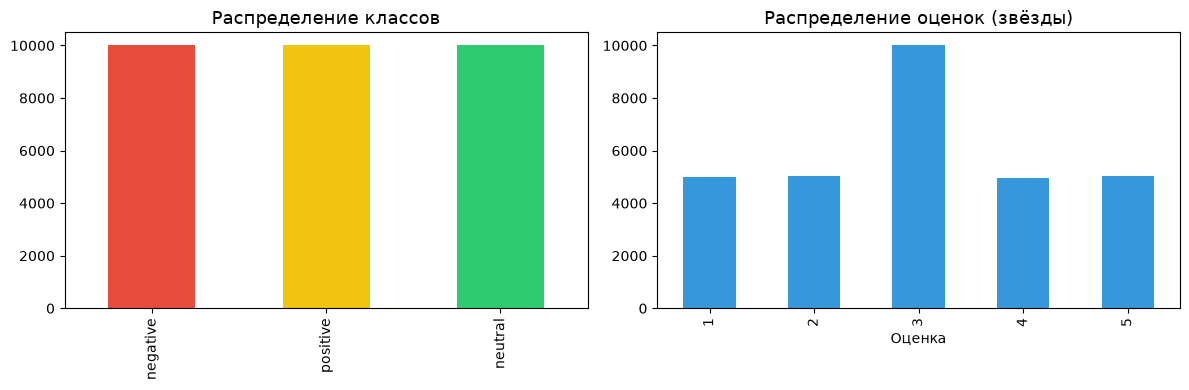

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["#e74c3c", "#f1c40f", "#2ecc71"])
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("")
df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#3498db")
axes[1].set_title("Распределение оценок (звёзды)")
axes[1].set_xlabel("Оценка")
plt.tight_layout()
plt.show()

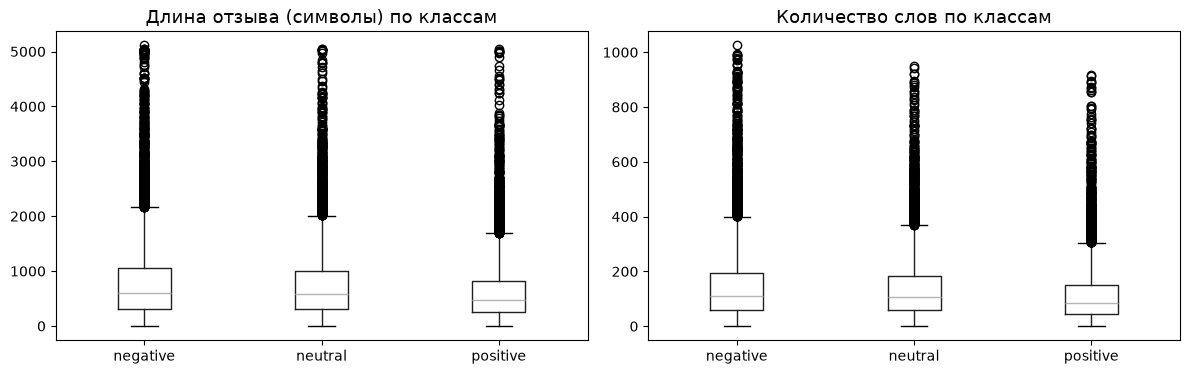

text_length        word_count       
                 mean median       mean median
sentiment                                     
negative        807.9  598.0      149.3  111.0
neutral         758.0  577.0      138.5  106.0
positive        626.5  464.0      113.7   84.0

In [4]:
df["text_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column="text_length", by="sentiment", ax=axes[0], grid=False)
axes[0].set_title("Длина отзыва (символы) по классам")
axes[0].set_xlabel("")
df.boxplot(column="word_count", by="sentiment", ax=axes[1], grid=False)
axes[1].set_title("Количество слов по классам")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

df.groupby("sentiment")[["text_length", "word_count"]].agg(["mean", "median"]).round(1)

In [5]:
for lab in ["negative", "neutral", "positive"]:
    print(f"--- {lab} ---")
    for t in df[df.sentiment == lab]["review"].head(2):
        print("•", t[:220].replace("\n", " "), "…")
    print()

--- negative ---
• Stayed here for 3 nights.  Hotel employees were great.  Called room service my last night for 30 minutes and no answer.  Unfortunatly I called the front desk after room service closed and was told they could not me.  Wil …
• This place was well conceived of, but the sheer size of it and the amount of people walking through it quite nearly caused me to have a panic attack. I was with a group and i realized if I let them out of my sight i woul …

--- neutral ---
• GREAT food, bad execution. \n\nTook my girlfriend to Mastro's Ocean Club last night for her birthday. My parents and I had been there for their anniversary last year, and because of some snafus with the service, Mastro's …
• This place could have easily had 5 stars. They brought my food out to my table. The fries were great. The burger was big...and that is about it had going for it. My meat seemed over cooked and dried out. I had a huge wed …

--- positive ---
• What is your go-to place to eat in Vegas?? I a

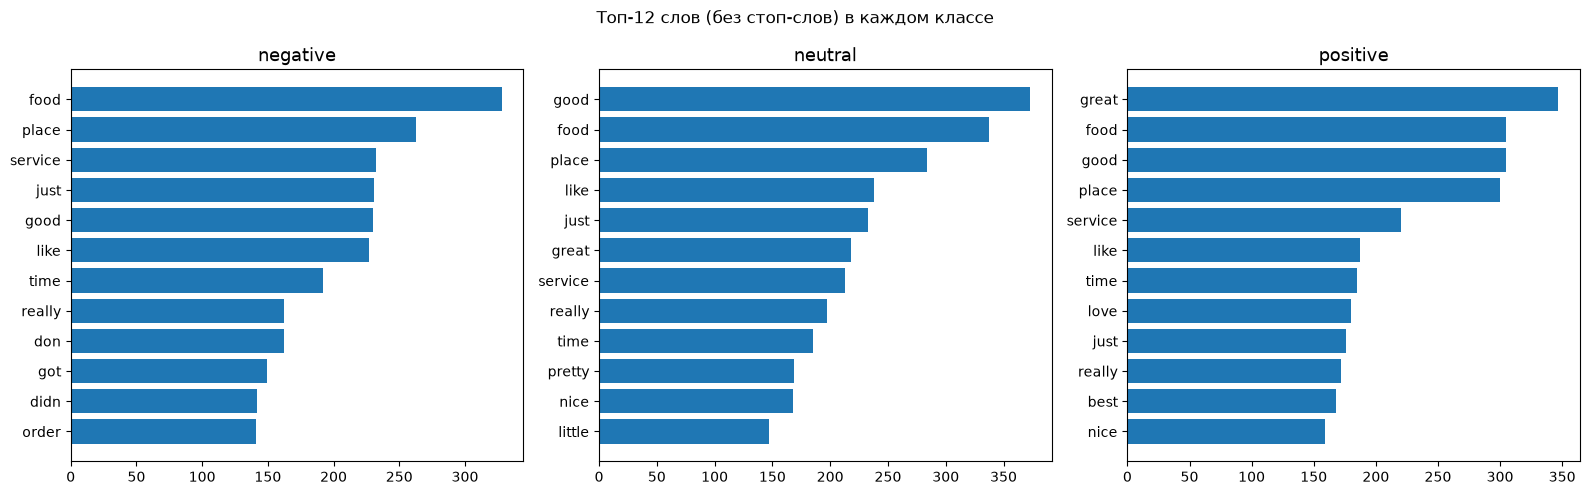

In [6]:
def top_words(texts, n=12):
    vec = TfidfVectorizer(stop_words="english", max_features=20000)
    m = vec.fit_transform(texts)
    scores = np.asarray(m.sum(axis=0)).ravel()
    idx = np.argsort(scores)[::-1][:n]
    names = vec.get_feature_names_out()
    return [(names[i], int(scores[i])) for i in idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lab in zip(axes, ["negative", "neutral", "positive"]):
    words = top_words(df[df.sentiment == lab]["review"])
    ax.barh([w for w, _ in words][::-1], [c for _, c in words][::-1])
    ax.set_title(lab)
plt.suptitle("Топ-12 слов (без стоп-слов) в каждом классе")
plt.tight_layout()
plt.show()

**Выводы EDA:**
- Классы сбалансированы (по 10k), пропусков и дубликатов нет — предобработка сводится к текстовой.
- Негативные отзывы в среднем короче и эмоциональнее, позитивные — длиннее.
- В каждом классе есть характерная лексика: негатив — *terrible, worst, never*, позитив — *great, amazing, excellent*. Задача решаема по тексту.

## 2. Baseline: Naive Bayes

Классическая «первая» модель для текста. Все модели в проекте используют одни и те же признаки — TF-IDF (n-граммы 1–2, sublinear_tf, 50k признаков), чтобы сравнение было честным.


In [7]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])


def evaluate(model, X_tr, X_te, y_tr, y_te, name):
    res = {
        "model": name,
        "acc_train": round(accuracy_score(y_tr, model.predict(X_tr)), 4),
        "acc_test": round(accuracy_score(y_te, model.predict(X_te)), 4),
        "f1_macro_test": round(f1_score(y_te, model.predict(X_te), average="macro"), 4),
        "roc_auc_test": round(roc_auc_score(y_te, model.predict_proba(X_te), multi_class="ovr"), 4),
    }
    print(res)
    return res


baseline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 1), sublinear_tf=True, max_features=50_000)),
    ("clf", MultinomialNB()),
])
baseline.fit(X_train, y_train)
baseline_res = evaluate(baseline, X_train, X_test, y_train, y_test, "Naive Bayes (baseline)")

Train: 24000  Test: 6000


{'model': 'Naive Bayes (baseline)', 'acc_train': 0.7685, 'acc_test': 0.6578, 'f1_macro_test': 0.6608, 'roc_auc_test': 0.8426}


## 3. Улучшенные модели

Пробуем три модели на тех же TF-IDF bigram-признаках:
1. **Logistic Regression** — линейная, быстрая, сильная на тексте.
2. **XGBoost** — градиентный бустинг, обучается на GPU (`device='cuda'`).
3. **LinearSVC** (с калибровкой вероятностей) — линейный SVM.


In [8]:
logreg = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=50_000)),
    ("clf", LogisticRegression(max_iter=1000, C=4.0)),
])
logreg.fit(X_train, y_train)
logreg_res = evaluate(logreg, X_train, X_test, y_train, y_test, "Logistic Regression (bigram)")

{'model': 'Logistic Regression (bigram)', 'acc_train': 0.9798, 'acc_test': 0.7343, 'f1_macro_test': 0.7345, 'roc_auc_test': 0.891}


In [9]:
class LabelEncodingXGB(BaseEstimator, ClassifierMixin):
    """XGBClassifier с кодированием строковых лейблов (xgboost 3.3 требует int-лейблы)."""

    def __init__(self, **kwargs):
        self.clf = xgb.XGBClassifier(**kwargs)
        self.le = LabelEncoder()

    def fit(self, X, y):
        self.classes_ = np.unique(np.asarray(y))
        self.clf.fit(X, self.le.fit_transform(y))
        return self

    def predict(self, X):
        return self.classes_[self.clf.predict(X)]

    def predict_proba(self, X):
        return self.clf.predict_proba(X)


xgb_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=50_000)),
    ("clf", LabelEncodingXGB(
        n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.9,
        colsample_bytree=0.8, eval_metric="mlogloss", tree_method="hist",
        device="cuda", random_state=RANDOM_STATE, n_jobs=4,
    )),
])
xgb_model.fit(X_train, y_train)
xgb_res = evaluate(xgb_model, X_train, X_test, y_train, y_test, "XGBoost (bigram, GPU)")

{'model': 'XGBoost (bigram, GPU)', 'acc_train': 0.8651, 'acc_test': 0.705, 'f1_macro_test': 0.7056, 'roc_auc_test': 0.872}


In [10]:
svc = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=50_000)),
    ("clf", CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=2000), cv=3, method="sigmoid")),
])
svc.fit(X_train, y_train)
svc_res = evaluate(svc, X_train, X_test, y_train, y_test, "LinearSVC (bigram, calibrated)")

{'model': 'LinearSVC (bigram, calibrated)', 'acc_train': 0.9389, 'acc_test': 0.7453, 'f1_macro_test': 0.744, 'roc_auc_test': 0.8938}


In [11]:
results = pd.DataFrame([baseline_res, logreg_res, xgb_res, svc_res]).sort_values("f1_macro_test", ascending=False)
results

,model,acc_train,acc_test,f1_macro_test,roc_auc_test
3,"LinearSVC (bigram, calibrated)",0.9389,0.7453,0.7440,0.8938
1,Logistic Regression (bigram),0.9798,0.7343,0.7345,0.8910
2,"XGBoost (bigram, GPU)",0.8651,0.7050,0.7056,0.8720
0,Naive Bayes (baseline),0.7685,0.6578,0.6608,0.8426


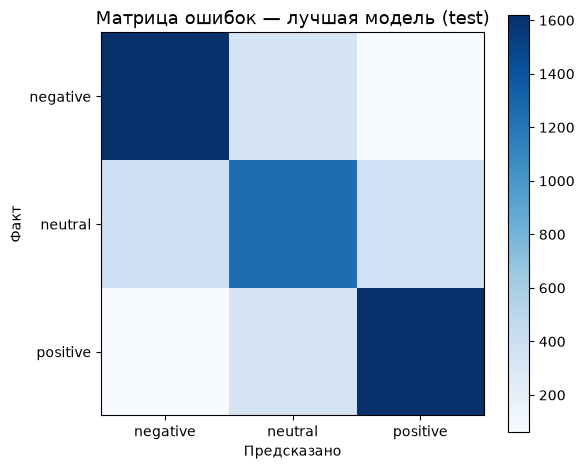

In [12]:
best = svc
cm = confusion_matrix(y_test, best.predict(X_test))
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(3), ["negative", "neutral", "positive"])
plt.yticks(range(3), ["negative", "neutral", "positive"])
plt.xlabel("Предсказано")
plt.ylabel("Факт")
plt.title("Матрица ошибок — лучшая модель (test)")
plt.tight_layout()
plt.show()

## 4. Сохранение модели

In [13]:
joblib.dump(best, MODEL_DIR / "best_pipeline.pkl")
joblib.dump(results.set_index("model"), MODEL_DIR / "metrics.pkl")
print("Saved:", MODEL_DIR / "best_pipeline.pkl")

Saved: C:\Users\79021\OneDrive - РУТ (МИИТ)\Рабочий стол\mukhit\review_analyst\model\best_pipeline.pkl


## 5. Мультиязычная модель: fine-tuned DistilBERT

Классические модели выше понимают только английский: на RU/KZ-отзывах TF-IDF-модель
даёт ~40% accuracy (случайный уровень для 3 классов). Поэтому рабочая модель приложения —
fine-tuned мультиязычный трансформер.

**Рецепт** (полный код — `scripts/finetune_multilingual.py`):
- База: `lxyuan/distilbert-base-multilingual-cased-sentiments-student` (135M) — чекпоинт,
  **преобученный на 3-классовой тональности**, а не обычный MLM. Это ключевой выбор:
  с обычного `distilbert-base-multilingual-cased` модель схлопывает всё в «нейтрал»
  на мягких описательных отзывах.
- Голова классификатора базовой модели **сохраняется** (не переинициализируется) и
  дообучается на месте — модель остаётся уверенной на однозначных отзывах.
- Данные: 30 859 отзывов — Yelp (EN 10k), rureviews + clapAI/MultiLingualSentiment
  (RU 20k: товарный + общедоменный), R3iwan/entertainment-reviews-kazakh (KZ ~1k).
- 5 эпох, fp16, batch 16×2 (grad accum), lr 2e-5, max_length 128. ~10 мин на RTX 3050 Ti (4GB).

Ниже загружаем обученную модель и оцениваем на выделенном test-наборе
(4 250 отзывов; RU test — только общедоменные отзывы, т.к. это реальный сценарий приложения).

In [14]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MT_DIR = BASE_DIR / "model" / "multilingual"
tok = AutoTokenizer.from_pretrained(str(MT_DIR))
mt = AutoModelForSequenceClassification.from_pretrained(str(MT_DIR))
device = "cuda" if torch.cuda.is_available() else "cpu"
mt.to(device).eval()
CLASSES = ["positive", "neutral", "negative"]  # порядок головы базовой модели
print("Model loaded:", MT_DIR, "| device:", device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded: C:\Users\79021\OneDrive - РУТ (МИИТ)\Рабочий стол\mukhit\review_analyst\model\multilingual | device: cuda


In [15]:
import json

def load_jsonl(p):
    return [json.loads(l) for l in open(p, encoding="utf-8")]

test = load_jsonl(BASE_DIR / "data" / "processed" / "test.jsonl")
texts = [r["text"] for r in test]
gold = [r["label"] for r in test]
langs = [r["lang"] for r in test]

all_probs = []
with torch.no_grad():
    for i in range(0, len(texts), 256):
        b = tok(texts[i:i+256], truncation=True, max_length=128, padding=True,
                return_tensors="pt").to(device)
        all_probs.append(torch.softmax(mt(**b).logits, dim=-1).cpu().numpy())
probs = np.concatenate(all_probs)
preds = probs.argmax(axis=-1)

rows = []
for lang in ("en", "ru", "kz"):
    m = np.array([l == lang for l in langs])
    rows.append({
        "lang": lang, "n": int(m.sum()),
        "acc": round(accuracy_score(np.array(gold)[m], preds[m]), 4),
        "f1_macro": round(f1_score(np.array(gold)[m], preds[m], average="macro"), 4),
        "roc_auc": round(roc_auc_score(np.array(gold)[m], probs[m],
                                       multi_class="ovr", average="macro"), 4),
    })
rows.append({"lang": "overall", "n": len(gold),
             "acc": round(accuracy_score(gold, preds), 4),
             "f1_macro": round(f1_score(gold, preds, average="macro"), 4),
             "roc_auc": round(roc_auc_score(gold, probs, multi_class="ovr",
                                            average="macro"), 4)})
pd.DataFrame(rows)

,lang,n,acc,f1_macro,roc_auc
0,en,2000,0.6820,0.6845,0.8507
1,ru,2000,0.8140,0.8141,0.9335
2,kz,250,1.0000,1.0000,1.0000
3,overall,4250,0.7628,0.7638,0.9062


**Результаты по языкам:** RU — сильнейший (F1 0.814, AUC 0.934) на честном общедоменном
test-наборе. KZ = 1.0 завышен малой выборкой (250) и узким развлекательным доменом.
EN — слабейший (0.685): 3-классовая задача Yelp объективно сложнее товарных отзывов.

**Проверенные вручную провалы** (документируются, а не скрываются):
- отрицание/контекст: «Персонал оперативно поменял *грязные* салфетки» (похвала) → негатив;
- слабый позитив → нейтрал: «Prices were competitive...» → нейтрал 0.83;
- смешанные отзывы: «Всё понравилось, но больше сюда не приду» → позитив 0.83;
- RU food-домен: bias базовой модели («суп был вкусным» → негатив).

135M-трансформер — надёжный классификатор однозначных отзывов, но не робастный
анализатор нюансов (ирония, отрицание). Для этого нужен заметно более крупный модель.

## 6. AI-часть: LLM-отчёт по негативным отзывам

LLM (локальная Qwen 27B через OpenAI-совместимый API) получает выборку негативных отзывов и пишет отчёт для бизнеса: основные жалобы и конкретные рекомендации. Тот же код используется в FastAPI-приложении (`app.py`).
Ключ хранится в `.env` (не коммитится).


In [16]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(BASE_DIR / ".env")
client = OpenAI(base_url=os.environ["LLM_API_BASE"], api_key=os.environ["LLM_API_KEY"])
LLM_MODEL = os.environ.get("LLM_MODEL", "unknown")


def llm_report(negative_reviews, max_reviews=15, max_tokens=1600):
    sample = "\n\n".join(f"[{i+1}] {t[:600]}" for i, t in enumerate(negative_reviews[:max_reviews]))
    prompt = (
        "Ты — аналитик для бизнеса. Ниже приведены негативные отзывы клиентов. "
        "Напиши краткий отчёт на русском языке: 1) 3-5 основных жалоб (списком), "
        "2) 3-5 конкретных рекомендаций по улучшению (списком). "
        "Будь конкретен, ссылайся на отзывы. Не более 250 слов.\n\n"
        f"Отзывы:\n{sample}"
    )
    resp = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}},
    )
    return resp.choices[0].message.content


neg_test = X_test[y_test == "negative"]
report = llm_report(list(neg_test.head(15)))
print(report)

### Отчёт: Анализ негативной обратной связи

**1. Основные жалобы клиентов:**
*   **Падение качества и свежие ингредиенты:** Постоянные клиенты отмечают, что еда стала посредственной (отзывы [1], [13]). Упоминается жесткое мясо, вялые крылья, несвежие лимоны ([6]), твердое «цементное» глазурь на печенье ([10]) и общая пресность блюд ([15]).
*   **Неадекватное ценообразование:** Клиенты считают блюда переоцененными относительно малых порций и низкого качества ([1], [12], [15]).
*   **Низкий уровень сервиса и коммуникации:** Жалобы на отсутствие реакции на звонки по ремонту ([7]), медленный и грубый сервис в drive-thru ([5]), молчаливость официантов ([6]) и провалы в обслуживании гостей с животными ([4]).
*   **Проблемы с чистотой и условиями:** Использование стиропора ([3]), грязные ковер после обработки ([4]), тесные, скученные пространства с ветхими стульями ([8]) и закрытые часы работы без предупреждения ([2]).
*   **Невыполнение условий акций:** Клиенты столкнулись с тем, что обещан

## Выводы

- **Классические модели (EN):** baseline (Naive Bayes) дал F1 macro ≈ 0.66, лучшая — **LinearSVC** с bigram-признаками — ≈ 0.74.
- **Важное наблюдение:** XGBoost (≈ 0.71) *проигрывает* линейным моделям (LogReg 0.73, LinearSVC 0.74) на разреженных TF-IDF-признаках: древовидные модели плохо работают с высокомерными разреженными текстовыми фичами.
- **Рабочая модель — fine-tuned мультиязычный DistilBERT:** overall F1 0.764, RU 0.814 (общедоменный test), EN 0.685. Ключевые решения: sentiment-преобученная база (а не обычный MLM) и сохранение её головы — без этого модель схлопывалась в «нейтрал» на мягких отзывах.
- **Честные ограничения:** модель систематически ошибается на отрицании, слабом позитиве, смешанных и ироничных отзывах; KZ — только развлекательный домен (открытых KZ бизнес-отзывов нет); KZ-метрики завышены малой выборкой.
- **AI-часть** превращает сырые предсказания в понятный бизнес-отчёт: именно это делает проект гибридным и пригодным для реального продукта.
- Дальше: больше KZ-данных (бизнес-домен), более крупная модель или синтетические данные для нюансов (ирония/отрицание), RAG по базе знаний заведения, A/B-сравнение промптов для LLM, Docker-деплой.